Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [23]:
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import interp1d

plt.rcParams["figure.constrained_layout.use"] = True

In [60]:
np.random.seed(123)

n_trials = 15
x = np.arange(0, n_trials)

mu_hr, sigma_hr = 75.0, 3.0
mu_bel, sigma_bel = 45.0, 5.0
alpha, beta = -10.0, 5.0
heart_rates = np.random.normal(mu_hr, sigma_hr, n_trials) + np.sin(x * .1)

f = interp1d(x, heart_rates, kind="cubic")
new_heart_rate = f(np.arange(0, n_trials-1, .001))

In [61]:
def weighted_bayesian_update(
    mu_0: float, mu_1: float, pi_0: float, pi_1: float, omega: float
):
    """Bayesian update for the mean and precision of a normal distribution."""
    pi = (1 - omega) * pi_0 + omega * pi_1
    mu = ((1 - omega) * mu_0 * pi_0 + omega * mu_1 * pi_1) / pi
    return mu, pi

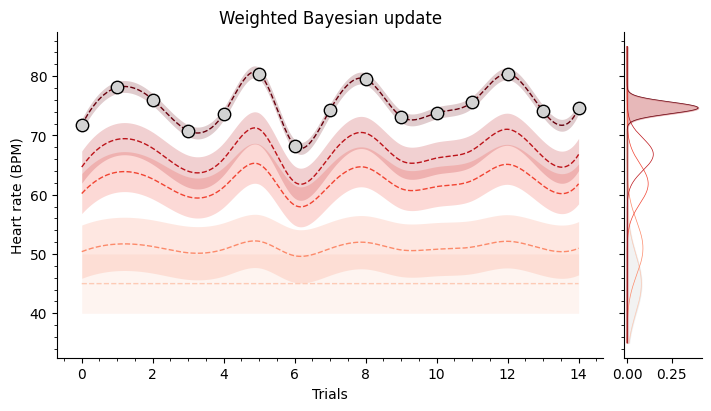

In [80]:
_, axs = plt.subplots(figsize=(7, 4), ncols=2, sharey=True, gridspec_kw={'width_ratios': [7, 1]})

axs[0].scatter(
    x,
    heart_rates,
    s=80,
    color="lightgrey",
    edgecolor="k",
    zorder=10
)

for omega, color in zip([0.0, 0.01, 0.05, 0.1, 1.0], plt.cm.Reds(np.linspace(0.2, 1, 5))):

    mu, pi = weighted_bayesian_update(mu_bel, heart_rates, 1/sigma_bel**2, 1.0, omega)
    f = interp1d(x, mu, kind="cubic")
    new_mu = f(np.arange(0, n_trials-1, .001))
    
    axs[0].fill_between(
        x=np.arange(0, n_trials-1, .001),
        y1=new_mu - np.sqrt(1/pi),
        y2=new_mu + np.sqrt(1/pi),
        color=color,
        alpha=0.2,
        linewidth=0
    )

    axs[0].plot(
        np.arange(0, n_trials-1, .001),
        new_mu,
        linestyle="--",
        linewidth=1,
        color=color,
    )


axs[0].set(title="Weighted Bayesian update", ylabel="Heart rate (BPM)")
axs[0].minorticks_on()

axs[0].set(xlabel="Trials")

x2 = np.linspace(35, 85, 1000)
for omega, color in zip([0.0, 0.01, 0.05, 0.1, 1.0], plt.cm.Reds(np.linspace(0.2, 1, 5))):
    # extract the sufficient statistics from the input node (and parents)
    mu, pi = weighted_bayesian_update(mu_bel, heart_rates[-1], 1/sigma_bel**2, 1.0, omega)

    # the model expectations
    axs[1].plot(
        norm(mu, np.sqrt(1 / pi)).pdf(x2),
        x2,
        color=color,
        label=rf"$\lambda = $ {round(omega, 2)}",
        linewidth=.5
    )

# the sampling distribution
axs[1].fill_betweenx(x2, norm(mu_bel, sigma_bel).pdf(x2), color="grey", alpha=0.1)
axs[1].fill_betweenx(x2, norm(heart_rates[-1], 1.0).pdf(x2), color="#c44e52", alpha=0.4)

sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_3_illustration.svg")